## <div align="center">**SSC5974 - Métodos Computacionais Aplicados ao Mercado Financeiro**</div>
## <div align="center">**Trabalho 2 - Parte 2 - Trading**</div>
## <div align="center">**Matheus Queiroz Mota - 16767388**</div>

### **Fatores Preditivos (Feature Engineering)**

O vetor de entrada foi rigorosamente filtrado para apenas nove variáveis essenciais, prevenindo a maldição da dimensionalidade e o sobreajuste (*overfitting*). As *features* dividem-se em quatro grupos:

* **Força e Direção (`ret_x`, `macd_diff`, `adx`):** Mensuram o *momentum* direcional e tendências do ativo.
* **Risco e Dispersão (`atr_r`, `bb_width`):** Capturam a volatilidade latente e a amplitude diária dos movimentos.
* **Fluxo de Capital (`vol_rel`):** Avalia a pressão institucional através do volume relativo.
* **Ação do Preço (`candle_body`):** Analisa a estrutura intradiária de força entre compradores e vendedores.

### **Features do Modelo**


- **'ret_1', 'ret_5', 'ret_10':** Momentum
- **'atr_r', 'bb_width':** Volatilidade
- **'macd_diff', 'adx':** Tendência
- **'vol_rel':** Volume
- **'candle_body':** Price Action


### **Modelos de Classificação**

Para traduzir os indicadores técnicos em sinais de negociação, a estratégia utilizou algoritmos com diferentes mecânicas de aprendizado:

* **Random Forest:** Árvores de decisão com profundidade limitada e amostras por folha elevadas, configuradas para ignorar ruídos estocásticos do mercado.
* **CatBoost:** Modelo de *boosting* com aprendizado lento e regularização matemática, forçando o algoritmo a focar em tendências reais e evitar falsos rompimentos.
* **SVM:** Adotou *kernel* Gaussiano não-linear para criar fronteiras de decisão curvas e mapear relações complexas entre os indicadores.

### **Estrutura de Treinamento e Simulação**

O problema foi modelado sob premissas para refletir a viabilidade na realidade:

* **Barreiras Triplas:** Variável alvo dinâmica (compra, venda ou inércia) baseada no primeiro toque do preço em limites de Lucro, Risco ou Tempo Máximo, todos ajustados pela volatilidade (ATR).
* **O *Shift*:** Sem deslocamento temporal no treino (o alvo das barreiras já embute o desfecho futuro), mas com *shift* de um dia obrigatório no simulador para garantir a execução apenas no pregão seguinte, anulando o viés de antecipação (*look-ahead bias*).
* **Validação *Out-of-Sample*:** Divisão cronológica estrita da base de dados. O desempenho contra o *Buy and Hold* foi validado em cenários totalmente não vistos, com deduções realistas de custos operacionais.

In [280]:
#%pip install ta -q

In [281]:
#!pip install yfinance --upgrade --no-cache-dir -q
#%pip install catboost -q


In [282]:
import ta
from ta import add_all_ta_features
from ta.utils import dropna
import yfinance as yf

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.multioutput import MultiOutputClassifier

from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import MACD, ADXIndicator
from ta.volume import OnBalanceVolumeIndicator
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix

sns.set(style='whitegrid')


## **Ações:**

Como descrito no relatório final, as ações utilizadas no backtest e análise do modelo serão a da Petrobras **(PETR4)** e AMBEV **(ABEV3)**. A ideia é verificar o desempenho e ganho dos modelos de Aprendizado de Máquina em ações que tendem a ter comportamento mais volátil e sensível (PETR4), e ações mais estáveis (ABEV3).

In [283]:
start_date = '2013-01-01'
end_date   = '2025-12-31'
#eqtl3 = yf.download('EQTL3.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]
petr4 = yf.download('PETR4.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]
#itub4 = yf.download('ITUB4.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]
#egie3 = yf.download('EGIE3.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]
ambev = yf.download('ABEV3.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]
#embraer = yf.download('EMBJ3.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]
#sabesp = yf.download('SBSP3.SA', start=start_date, end=end_date, interval='1d', auto_adjust=True)[['Open', 'High', 'Low', 'Close', 'Volume']]

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [284]:
def triple_barrier_labeling(df, atr_period=14, max_holding=10, tp_mult=2.0, sl_mult=1.0):
    """
    Rotulagem de trades usando o método Triple Barrier Labeling.
    
    Parâmetros:
    -----------
    df : pandas.DataFrame
        DataFrame contendo colunas OHLC (Open, High, Low, Close).
    
    atr_period : int, padrão=14
        Período utilizado para calcular o Average True Range (ATR).
        Define a volatilidade usada para montar as barreiras de Take Profit e Stop Loss.
    
    max_holding : int, padrão=10
        Número máximo de dias (barras) que uma posição pode ficar aberta.
        Se nenhuma barreira for tocada nesse período, o trade é fechado (label = 0).
    
    tp_mult : float, padrão=2.0
        Multiplicador do ATR para a barreira superior (Take Profit).
        Exemplo: tp_mult=2.0 significa Take Profit = preço_entrada + 2.0 * ATR.
    
    sl_mult : float, padrão=1.0
        Multiplicador do ATR para a barreira inferior (Stop Loss).
        Exemplo: sl_mult=1.0 significa Stop Loss = preço_entrada - 1.0 * ATR.
    
    Retorno:
    --------
    pd.Series
        Série com os rótulos: 
            +1 -> Take Profit atingido primeiro
            -1 -> Stop Loss atingido primeiro
             0 -> Nenhum dos dois (holding máximo atingido)
    """
    closes      = df["Close"].values
    opens       = df["Open"].values
    highs       = df["High"].values
    lows        = df["Low"].values

    atrs        = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["Close"], window=atr_period).average_true_range().values

    n           = len(df)
    labels      = np.zeros(n, dtype=float)

    for i in range(n - max_holding):
        tp    = closes[i] + tp_mult * atrs[i]
        sl    = closes[i] - sl_mult * atrs[i]
        label = 0

        for j in range(1, max_holding + 1):
            idx    = i + j
            tp_hit = highs[idx] >= tp
            sl_hit = lows[idx]  <= sl

            if tp_hit and sl_hit:
                if opens[idx] >= tp:
                    label = +1
                elif opens[idx] <= sl:
                    label = -1
                else:
                    label = +1 if (tp - closes[i]) <= (closes[i] - sl) else -1
                break
            elif tp_hit:
                label = +1
                break
            elif sl_hit:
                label = -1
                break

        labels[i] = label

    labels[-max_holding:] = np.nan
    return pd.Series(labels, index=df.index, name="label")


### **Observação:**

Como descrito no Relatório Final, há diversas features que foram desenvolvidas. Porém, para evitar problemas como a dimensão de alta dimensionalidade e alta correlação entre multiplos pares, optei por selecionar um grupo específico. Além disso, é totalmente possível alterar o tamanho do treino e teste.

In [ ]:
ATIVOS = {
    'PETR4.SA': petr4,
    'ABEV3.SA': ambev,
}


def preparar_ativo(df_bruto):
    """
    Executa o pipeline completo de pré-processamento, engenharia de features e 
    particionamento de dados para um ativo financeiro específico.

    Esta função atua na preparação de dados para os modelos de 
    Machine Learning.

    Passos executados:
    1. Padronização: Renomeia as colunas para o padrão universal OHLCV.
    2. Rotulagem (Target): Aplica o Método de Barreiras Triplas dinâmico 
       (ajustado por ATR) para gerar os rótulos de compra (1), venda (-1) ou inércia (0).
    3. Engenharia de Features: Calcula indicadores técnicos cobrindo momento (MACD, RSI), 
       volatilidade (Bollinger, ATR), tendência (ADX), volume (OBV) e price action.
    4. Limpeza e Seleção: Remove valores nulos (gerados pela janela de lookback dos indicadores) 
       e filtra o dataset para manter apenas as 9 features essenciais, evitando overfitting.
    5. Split Treino/Teste: Divide as matrizes cronologicamente em 55% para treino 
       e 45% para teste, isolando o ambiente out-of-sample e prevenindo data leakage.

    Entradas:
        df_bruto (pd.DataFrame): DataFrame bruto baixado via yfinance ou similar.

    Retornos:
        dict: Pacote encapsulado com os dados prontos para inserção nos modelos:
            - 'dados': DataFrame final limpo e processado.
            - 'feature_cols': Lista com os nomes das features utilizadas.
            - 'din', 'dout': Matrizes numpy completas (entradas e alvos).
            - 'train_n': Índice (linha) de corte temporal do split.
            - 'train_in', 'train_out': Matrizes de treinamento (passado).
            - 'test_in', 'test_out': Matrizes de teste/validação (futuro).
    """
    df = df_bruto.copy()
    df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Triple Barrier Labeling 
    df['Action-tb'] = triple_barrier_labeling(
        df, atr_period=16, max_holding=18, tp_mult=2.5, sl_mult=2
    )

    # Bandas de Bollinger
    ind_bb = BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['bb_hb'] = ind_bb.bollinger_hband()
    df['bb_lb'] = ind_bb.bollinger_lband()
    df['bb_mb'] = ind_bb.bollinger_mavg()
    df['bb_hr'] = df['bb_hb'] / df['Close']
    df['bb_lr'] = df['bb_lb'] / df['Close']
    df['bb_mr'] = df['bb_mb'] / df['Close']

    ind_rsi = RSIIndicator(close=df['Close'], window=14)
    df['RSI'] = ind_rsi.rsi() / 100.0

    # Momentum
    macd_ind = MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
    df['macd']        = macd_ind.macd() / df['Close']
    df['macd_signal'] = macd_ind.macd_signal() / df['Close']
    df['macd_diff']   = macd_ind.macd_diff() / df['Close']

    adx_ind = ADXIndicator(high=df['High'], low=df['Low'], close=df['Close'], window=14)
    df['adx'] = adx_ind.adx() / 100.0

    df['ret_1']  = df['Close'].pct_change(1)
    df['ret_5']  = df['Close'].pct_change(5)
    df['ret_10'] = df['Close'].pct_change(10)

    # Volatilidade
    atr_ind = ta.volatility.AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14)
    df['atr_r'] = atr_ind.average_true_range() / df['Close']
    df['bb_width'] = (df['bb_hb'] - df['bb_lb']) / df['Close']

    # Volume
    obv_ind = OnBalanceVolumeIndicator(close=df['Close'], volume=df['Volume'])
    df['obv_chg'] = obv_ind.on_balance_volume().pct_change(5)
    df['vol_rel'] = df['Volume'] / df['Volume'].rolling(20).mean()

    # Price action / candle
    df['candle_body']  = (df['Close'] - df['Open']) / df['Open']
    df['candle_range'] = (df['High'] - df['Low']) / df['Open']
    df['gap_open']     = df['Open'] / df['Close'].shift(1) - 1

    # Sazonalidade
    dia_semana = df.index.dayofweek
    df['dow_sin'] = np.sin(2 * np.pi * dia_semana / 5)
    df['dow_cos'] = np.cos(2 * np.pi * dia_semana / 5)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    # Features
    # Caso Queira trocar as features (remover ou adicionar), basta colocar no nome delas aqui!
    features_principais = [
        'ret_1', 'ret_5', 'ret_10',      # Momentum
        'atr_r', 'bb_width',             # Volatilidade
        'macd_diff', 'adx',              # Tendência
        'vol_rel',                       # Volume
        'candle_body'                    # Price Action
    ]
    feature_cols = features_principais

    din = df[feature_cols].reset_index().drop(['Date'], axis=1).to_numpy()
    dout = df['Action-tb'].reset_index().drop(['Date'], axis=1).to_numpy()

    # Split treino/teste (também possível ajustar aqui)
    n_total = din.shape[0]
    train_frac = 0.55
    train_n = int(n_total * train_frac)

    train_in  = din[0:train_n]
    train_out = dout[0:train_n]
    test_in   = din[train_n:]
    test_out  = dout[train_n:]

    return {
        'dados': df,
        'feature_cols': feature_cols,
        'din': din,
        'dout': dout,
        'train_n': train_n,
        'train_in': train_in,
        'train_out': train_out,
        'test_in': test_in,
        'test_out': test_out,
    }


# Pré-processa os dois ativos uma única vez (evita recalcular indicadores a cada modelo)
ATIVOS_PREPARADOS = {ticker: preparar_ativo(df_bruto) for ticker, df_bruto in ATIVOS.items()}

for ticker, pack in ATIVOS_PREPARADOS.items():
    print(f"{ticker}: {pack['train_in'].shape[0]} amostras treino | {pack['test_in'].shape[0]} amostras teste")


PETR4.SA: 1750 amostras treino | 1432 amostras teste
ABEV3.SA: 1750 amostras treino | 1432 amostras teste


In [286]:
for ticker, pack in ATIVOS_PREPARADOS.items():
    train_out = pack['train_out']
    test_out = pack['test_out']
    
    # Contar distribuição no treino
    unique_train, counts_train = np.unique(train_out, return_counts=True)
    dist_train = dict(zip(unique_train, counts_train))
    
    # Contar distribuição no teste
    unique_test, counts_test = np.unique(test_out, return_counts=True)
    dist_test = dict(zip(unique_test, counts_test))
    
    print(f"\n{ticker}")
    print("=" * 50)
    print("Treino - Distribuição de rótulos:")
    for label in [-1, 0, 1]:
        count = dist_train.get(label, 0)
        pct = 100 * count / len(train_out)
        print(f"  Label {label:2d}: {count:4d} ({pct:6.2f}%)")
    
    print("\nTeste - Distribuição de rótulos:")
    for label in [-1, 0, 1]:
        count = dist_test.get(label, 0)
        pct = 100 * count / len(test_out)
        print(f"  Label {label:2d}: {count:4d} ({pct:6.2f}%)")


PETR4.SA
Treino - Distribuição de rótulos:
  Label -1:  708 ( 40.46%)
  Label  0:  316 ( 18.06%)
  Label  1:  726 ( 41.49%)

Teste - Distribuição de rótulos:
  Label -1:  518 ( 36.17%)
  Label  0:  309 ( 21.58%)
  Label  1:  605 ( 42.25%)

ABEV3.SA
Treino - Distribuição de rótulos:
  Label -1:  726 ( 41.49%)
  Label  0:  441 ( 25.20%)
  Label  1:  583 ( 33.31%)

Teste - Distribuição de rótulos:
  Label -1:  577 ( 40.29%)
  Label  0:  362 ( 25.28%)
  Label  1:  493 ( 34.43%)


In [ ]:
def criar_modelo(nome_modelo, random_state=42):
    """
        Função que criei para aglutinar os modelos que separei, mas é possível remover e adicionar novos modelos aqui

        - 'RandomForest' 
        - 'CatBoost'     
        - 'SVM'          
        
    nome_modelo : 'RandomForest' | 'CatBoost' | 'SVM'
    """
    if nome_modelo == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            min_samples_leaf=50,
            max_features='sqrt',
            class_weight='balanced',
            n_jobs=-1,
            random_state=random_state,
        )

    elif nome_modelo == 'CatBoost':
        return CatBoostClassifier(
            iterations=100,
            learning_rate=0.02,
            depth=4,
            l2_leaf_reg=3,
            random_strength=1.0,
            bagging_temperature=1.0,
            auto_class_weights='Balanced',
            random_seed=random_state,
            verbose=False,
        )

    elif nome_modelo == 'SVM':
        return SVC(
            random_state=random_state,
            kernel='rbf',
            degree=3,
        )

    else:
        raise ValueError(f"Modelo desconhecido: {nome_modelo!r}. Use 'RandomForest', 'CatBoost' ou 'SVM'.")


In [ ]:
import matplotlib.ticker as mtick

CORES_GRAFICOS = {
    'Buy & Hold':    "#319318",  
    'RandomForest':  '#2980B9',   
    'CatBoost':      '#D35400',  
    'SVM':           '#8E44AD',  
}

ORDEM_SERIES = ['Buy & Hold', 'RandomForest', 'CatBoost', 'SVM']


def gerar_plot(ax, label_y, titulo, fmt_pct=True, linha_zero=False):
    """
    Função responsável pelos plots
    """
    if fmt_pct:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel(label_y, fontweight='bold')
    ax.set_title(titulo, fontweight='bold', fontsize=12, loc='left')
    ax.grid(True, alpha=0.3)

    if linha_zero:
        ax.axhline(0, color='black', linestyle='-', linewidth=1)

    for linha in ax.get_lines():
        label = linha.get_label()
        if label == 'Buy & Hold':
            linha.set_linewidth(1.6)
            linha.set_linestyle('--')
            linha.set_alpha(0.75)
        elif label in CORES_GRAFICOS:
            linha.set_linewidth(2.4)
            linha.set_linestyle('-')
            linha.set_alpha(0.95)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()

# Obs: caso queira ver os gráficos de drawdown, retorno movel e volat, seguir as instruções mais abaixo

def calc_drawdown(serie_indice):
    """Drawdown percentual em relação ao pico histórico da série (em índice base 100)."""
    pico = serie_indice.cummax()
    return (serie_indice / pico - 1.0)


def calc_retorno_movel_anualizado(serie_indice, janela):
    """Retorno anualizado dentro de uma janela móvel de `janela` pregões."""
    ret_diario = serie_indice.pct_change()
    ret_acum_janela = (1 + ret_diario).rolling(janela).apply(lambda x: x.prod(), raw=True)
    return ret_acum_janela ** (252 / janela) - 1


def calc_vol_movel_anualizada(serie_indice, janela):
    """Volatilidade anualizada (desvio padrão dos retornos diários) em janela móvel."""
    ret_diario = serie_indice.pct_change()
    return ret_diario.rolling(janela).std() * np.sqrt(252)


### **Atenção: leitura dos gráficos**

A curva "Treinamento" mostra desempenho **in-sample** (dados que o modelo já viu durante o
`.fit`), portanto tende a superestimar a capacidade preditiva real do modelo. Apenas a curva
"Validação" (dados que o modelo nunca viu no treino) é uma medida honesta de desempenho
out-of-sample.

### **Observação**

Por questão visual, removi os gráficos de drawdown, retorno movel e volatilidade. Para exibir eles novamente, remover o código comentado em ''' ... ''' dentro da função **plotar_comparativo_ativo()**.


In [ ]:
def treinar_e_avaliar(ticker, nome_modelo, custo_transacao=0.001, mostrar_matriz_confusao=True):
    """
    Treina UM modelo para UM ativo, avalia (accuracy + classification_report +
    matriz de confusão) e roda o backtest.

    ticker      : chave de ATIVOS_PREPARADOS, ex.: 'PETR4.SA'
    nome_modelo : 'RandomForest' | 'CatBoost' | 'SVM'

    Retorna um dict com tudo que o comparativo final precisa: o DataFrame com
    'Saldo' calculado, os retornos de cada trade fechado (treino/teste) e o
    classificador treinado.
    """
    pack = ATIVOS_PREPARADOS[ticker]
    dados_ativo = pack['dados'].copy()
    train_n  = pack['train_n']
    train_in, train_out = pack['train_in'], pack['train_out']
    test_in, test_out   = pack['test_in'], pack['test_out']
    din = pack['din']

    titulo_base = f"{ticker} — {nome_modelo}"
    print("=" * 70)
    print(titulo_base)
    print("=" * 70)

    # Treino do Modelo
    clf = criar_modelo(nome_modelo)
    clf.fit(train_in, train_out.ravel())

    
    # Avaliação
    y_pred_train = clf.predict(train_in)
    y_pred_test  = clf.predict(test_in)

    print("Accuracy train:", metrics.accuracy_score(train_out, y_pred_train))
    print("Accuracy test: ", metrics.accuracy_score(test_out, y_pred_test))
    print("\nRelatório de classificação (teste):")
    print(classification_report(test_out, y_pred_test, zero_division=0))

    if mostrar_matriz_confusao:
        cm = confusion_matrix(test_out, y_pred_test, labels=[-1, 0, 1])
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Sell (-1)', 'Hold (0)', 'Buy (1)'],
                    yticklabels=['Sell (-1)', 'Hold (0)', 'Buy (1)'])
        plt.title(f'Matriz de Confusão (Teste) — {titulo_base}', fontweight='bold', fontsize=11)
        plt.ylabel('Verdadeiro')
        plt.xlabel('Predito')
        plt.tight_layout()
        plt.show()

    y_pred_all = clf.predict(din)
    dados_ativo.loc[:, 'ML-Action'] = y_pred_all

    # Backtest

    dados_ativo.loc[:, 'Saldo'] = 0.0
    saldo = 100.0
    comprado = 0
    val_neg = 0

    trades, trades_pos, media_pos, media_neg = 0, 0, 0, 0
    test_trades, test_trades_pos, test_media_pos, test_media_neg = 0, 0, 0, 0

    # Retornos individuais de cada trade fechado (para o gráfico de distribuição)
    retornos_trades_treino, retornos_trades_teste = [], []

    n = dados_ativo.shape[0]
    for i in range(0, n - 1):
        sinal = dados_ativo['ML-Action'].iloc[i]
        preco_execucao = dados_ativo['Close'].iloc[i + 1]
        is_test = (i + 1) >= train_n

        res_trade = None
        if sinal == 1 and comprado == 0:
            val_neg = preco_execucao
            comprado = 1
        elif sinal == 1 and comprado == -1:
            res_trade = val_neg / preco_execucao - 1 - custo_transacao
            comprado = 0
        elif sinal == -1 and comprado == 0:
            comprado = -1
            val_neg = preco_execucao
        elif sinal == -1 and comprado == 1:
            res_trade = preco_execucao / val_neg - 1 - custo_transacao
            comprado = 0

        if res_trade is not None:
            if res_trade > 0:
                trades_pos += 1
                media_pos += res_trade
            else:
                media_neg += res_trade
            trades += 1
            saldo = saldo * (1 + res_trade)

            if is_test:
                test_trades += 1
                retornos_trades_teste.append(res_trade)
                if res_trade > 0:
                    test_trades_pos += 1
                    test_media_pos += res_trade
                else:
                    test_media_neg += res_trade
            else:
                retornos_trades_treino.append(res_trade)

        dados_ativo.loc[dados_ativo.index[i + 1], 'Saldo'] = saldo

    dados_ativo.loc[dados_ativo.index[0], 'Saldo'] = 100.0

    print("\n--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---")
    if trades > 0:
            print("Trades total:", trades, "Trades positivos:", trades_pos,
                "(", round(trades_pos / trades * 100, 2), "%)")
            if trades_pos > 0:
                ret_pos = [r for r in (retornos_trades_treino + retornos_trades_teste) if r > 0]
                print("Media trades positivos:  ", round(media_pos / trades_pos * 100, 2), "%")
                print("Mediana trades positivos:", round(np.median(ret_pos) * 100, 2), "%")
            if trades > trades_pos:
                ret_neg = [r for r in (retornos_trades_treino + retornos_trades_teste) if r <= 0]
                print("Media trades negativos:  ", round(media_neg / (trades - trades_pos) * 100, 2), "%")
                print("Mediana trades negativos:", round(np.median(ret_neg) * 100, 2), "%")
            print("Rent. buy and hold:", round((dados_ativo['Close'].iloc[-1] / dados_ativo['Close'].iloc[0] - 1) * 100, 2), "%")
            print("Rent. ML trade:", round((dados_ativo['Saldo'].iloc[-1] / dados_ativo['Saldo'].iloc[0] - 1) * 100, 2), "%")
    else:
            print("Não foram feitos trades no período.")

    print("\n--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---")
    if test_trades > 0:
        print("Trades total:", test_trades, "Trades positivos:", test_trades_pos,
              "(", round(test_trades_pos / test_trades * 100, 2), "%)")
        if test_trades_pos > 0:
            ret_pos_teste = [r for r in retornos_trades_teste if r > 0]
            print("Media trades positivos:  ", round(test_media_pos / test_trades_pos * 100, 2), "%")
            print("Mediana trades positivos:", round(np.median(ret_pos_teste) * 100, 2), "%")
        if test_trades > test_trades_pos:
            ret_neg_teste = [r for r in retornos_trades_teste if r <= 0]
            print("Media trades negativos:  ", round(test_media_neg / (test_trades - test_trades_pos) * 100, 2), "%")
            print("Mediana trades negativos:", round(np.median(ret_neg_teste) * 100, 2), "%")
        rent_bh_teste = (dados_ativo['Close'].iloc[-1] / dados_ativo['Close'].iloc[train_n] - 1) * 100
        rent_ml_teste = (dados_ativo['Saldo'].iloc[-1] / dados_ativo['Saldo'].iloc[train_n] - 1) * 100
        print("Rent. Buy and Hold (Teste):", round(rent_bh_teste, 2), "%")
        print("Rent. ML trade (Teste):    ", round(rent_ml_teste, 2), "%")
    else:
        print("Não foram feitos trades no período de teste.")

    return {
        'ticker': ticker,
        'nome_modelo': nome_modelo,
        'clf': clf,
        'dados': dados_ativo,
        'train_n': train_n,
        'y_pred_test': y_pred_test,
        'retornos_trades_treino': retornos_trades_treino,
        'retornos_trades_teste': retornos_trades_teste,
    }


def plotar_comparativo_ativo(ticker, resultados_por_modelo):
    """
    Plota os 5 gráficos comparativos (Retorno Acumulado, Drawdown, Retorno Móvel,
    Volatilidade Móvel, Distribuição de Retornos) com o Buy & Hold e OS 3 MODELOS
    JUNTOS na mesma figura. Cada gráfico é gerado em 2 versões: Treino
    (in-sample) e Teste (out-of-sample).

    ticker                 : ex.: 'PETR4.SA'
    resultados_por_modelo  : dict {nome_modelo: dict retornado por treinar_e_avaliar},
                             ex.: {'RandomForest': resultado_rf, 'CatBoost': resultado_cb,
                                   'SVM': resultado_svm}
    """
    nomes_modelos = [m for m in ORDEM_SERIES if m in resultados_por_modelo]
    primeiro = next(iter(resultados_por_modelo.values()))
    train_n = primeiro['train_n']

    # DataFrame único: Close (Buy & Hold) + Saldo de cada modelo, todos pelo mesmo índice.
    base = primeiro['dados'][['Close']].rename(columns={'Close': 'Buy & Hold'})
    for nome_modelo in nomes_modelos:
        base[nome_modelo] = resultados_por_modelo[nome_modelo]['dados']['Saldo']

    n = base.shape[0]
    colunas_presentes = ['Buy & Hold'] + nomes_modelos
    cores_lista = [CORES_GRAFICOS[c] for c in colunas_presentes]

    for parte, ini, fim in [('Treino (in-sample)', 0, train_n), ('Teste (out-of-sample)', train_n, n)]:
        sub = base[colunas_presentes].iloc[ini:fim]
        if sub.shape[0] < 5:
            print(f"[{parte}] poucos dados para plotar, pulando.")
            continue

        norm = sub / sub.iloc[0] * 100

        janela_curta = 21 if fim - ini < 150 else 63
        janela_longa = 63 if fim - ini < 350 else 126

        # Gráfico 1: Retorno acumulado
        acc = (norm / norm.iloc[0] - 1) * 100
        ax = acc.plot(figsize=(15, 5), color=cores_lista)
        gerar_plot(ax, 'Retorno (%)', f'Retorno Acumulado — {ticker} [{parte}]')
        plt.show()

        '''# Gráfico 2: Drawdown
        dd = pd.DataFrame({col: calc_drawdown(norm[col]) for col in norm.columns}) * 100
        ax = dd.plot(figsize=(15, 5), color=cores_lista)
        gerar_plot(ax, 'Drawdown (%)', f'Drawdown — {ticker} [{parte}]')
        plt.show()

        # Gráfico 3: Retorno móvel anualizado
        mov = pd.DataFrame({col: calc_retorno_movel_anualizado(norm[col], janela_longa) for col in norm.columns}) * 100
        ax = mov.plot(figsize=(15, 5), color=cores_lista)
        gerar_plot(ax, 'Retorno Móvel (%)',
                                     f'Retorno Anualizado Móvel ({janela_longa}d) — {ticker} [{parte}]',
                                     linha_zero=True)
        plt.show()

        # Gráfico 4: Volatilidade móvel anualizada
        vol = pd.DataFrame({col: calc_vol_movel_anualizada(norm[col], janela_curta) for col in norm.columns}) * 100
        ax = vol.plot(figsize=(15, 5), color=cores_lista)
        gerar_plot(ax, 'Volatilidade (%)',
                                     f'Volatilidade Anualizada Móvel ({janela_curta}d) — {ticker} [{parte}]')
        plt.show()'''

        # Gráfico 5: Distribuição dos retornos por trade
        # Buy & Hold: distribuição dos retornos diários (referência de dispersão passiva).
        # Cada modelo: distribuição dos retornos por trade fechado no período.
        chave_periodo = 'retornos_trades_treino' if parte.startswith('Treino') else 'retornos_trades_teste'
        ret_diario_bh = norm['Buy & Hold'].pct_change().dropna() * 100

        fig, ax = plt.subplots(figsize=(15, 5))
        ax.hist(ret_diario_bh, bins=40, color=CORES_GRAFICOS['Buy & Hold'], alpha=0.45,
                label='Buy & Hold (retornos diários)', density=True)
        for nome_modelo in nomes_modelos:
            retornos_trades = resultados_por_modelo[nome_modelo][chave_periodo]
            if len(retornos_trades) > 0:
                ax.hist(np.array(retornos_trades) * 100,
                        bins=min(40, max(5, len(retornos_trades) // 2)),
                        color=CORES_GRAFICOS[nome_modelo], alpha=0.55,
                        label=f'{nome_modelo} (retorno por trade)', density=True)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_xlabel('Retorno (%)', fontweight='bold')
        ax.set_ylabel('Densidade', fontweight='bold')
        ax.set_title(f'Distribuição de Retornos — {ticker} [{parte}]', fontweight='bold', fontsize=12, loc='left')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=10)
        plt.tight_layout()
        plt.show()


#### PETR4.SA — Random Forest, CatBoost e SVM (comparativo)


PETR4.SA — RandomForest
Accuracy train: 0.5131428571428571
Accuracy test:  0.39664804469273746

Relatório de classificação (teste):
              precision    recall  f1-score   support

        -1.0       0.41      0.45      0.43       518
         0.0       0.29      0.30      0.29       309
         1.0       0.45      0.40      0.42       605

    accuracy                           0.40      1432
   macro avg       0.38      0.38      0.38      1432
weighted avg       0.40      0.40      0.40      1432



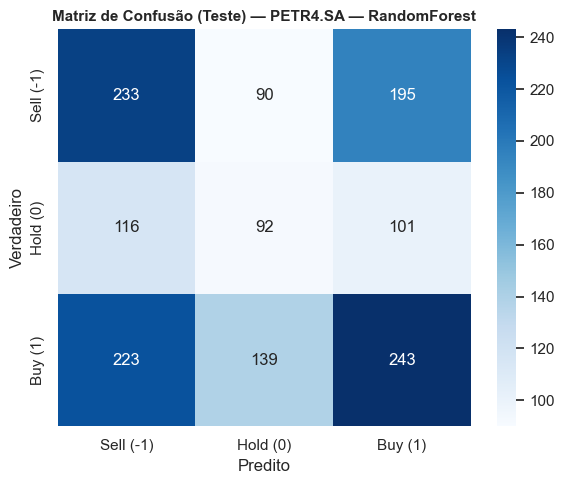


--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---
Trades total: 215 Trades positivos: 114 ( 53.02 %)
Media trades positivos:   10.14 %
Mediana trades positivos: 4.57 %
Media trades negativos:   -4.06 %
Mediana trades negativos: -3.08 %
Rent. buy and hold: 648.45 %
Rent. ML trade: 24276.43 %

--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---
Trades total: 103 Trades positivos: 54 ( 52.43 %)
Media trades positivos:   6.49 %
Mediana trades positivos: 3.72 %
Media trades negativos:   -3.48 %
Mediana trades negativos: -3.06 %
Rent. Buy and Hold (Teste): 374.19 %
Rent. ML trade (Teste):     345.35 %
PETR4.SA — CatBoost
Accuracy train: 0.5348571428571428
Accuracy test:  0.3840782122905028

Relatório de classificação (teste):
              precision    recall  f1-score   support

        -1.0       0.38      0.35      0.36       518
         0.0       0.29      0.29      0.29       309
         1.0       0.44      0.46      0.45       605

    accuracy                           

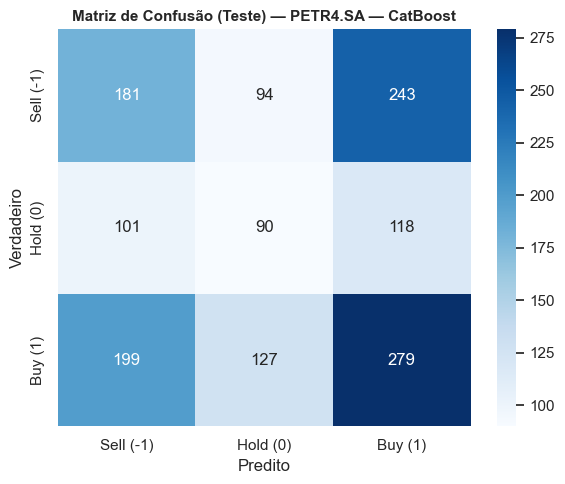


--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---
Trades total: 260 Trades positivos: 143 ( 55.0 %)
Media trades positivos:   9.39 %
Mediana trades positivos: 3.68 %
Media trades negativos:   -3.83 %
Mediana trades negativos: -2.41 %
Rent. buy and hold: 648.45 %
Rent. ML trade: 91938.22 %

--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---
Trades total: 140 Trades positivos: 71 ( 50.71 %)
Media trades positivos:   6.91 %
Mediana trades positivos: 3.01 %
Media trades negativos:   -3.53 %
Mediana trades negativos: -2.41 %
Rent. Buy and Hold (Teste): 374.19 %
Rent. ML trade (Teste):     505.3 %
PETR4.SA — SVM
Accuracy train: 0.4725714285714286
Accuracy test:  0.41480446927374304

Relatório de classificação (teste):
              precision    recall  f1-score   support

        -1.0       0.36      0.46      0.41       518
         0.0       0.19      0.01      0.02       309
         1.0       0.46      0.58      0.52       605

    accuracy                           0.41   

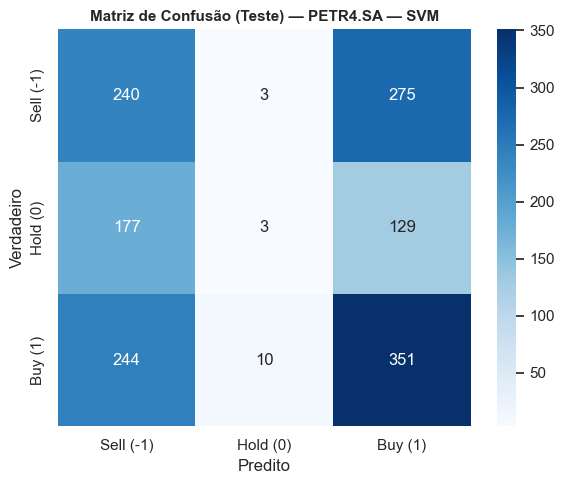


--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---
Trades total: 643 Trades positivos: 336 ( 52.26 %)
Media trades positivos:   4.13 %
Mediana trades positivos: 2.02 %
Media trades negativos:   -3.07 %
Mediana trades negativos: -2.16 %
Rent. buy and hold: 648.45 %
Rent. ML trade: 2335.84 %

--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---
Trades total: 304 Trades positivos: 157 ( 51.64 %)
Media trades positivos:   3.28 %
Mediana trades positivos: 1.86 %
Media trades negativos:   -2.51 %
Mediana trades negativos: -1.76 %
Rent. Buy and Hold (Teste): 374.19 %
Rent. ML trade (Teste):     180.43 %


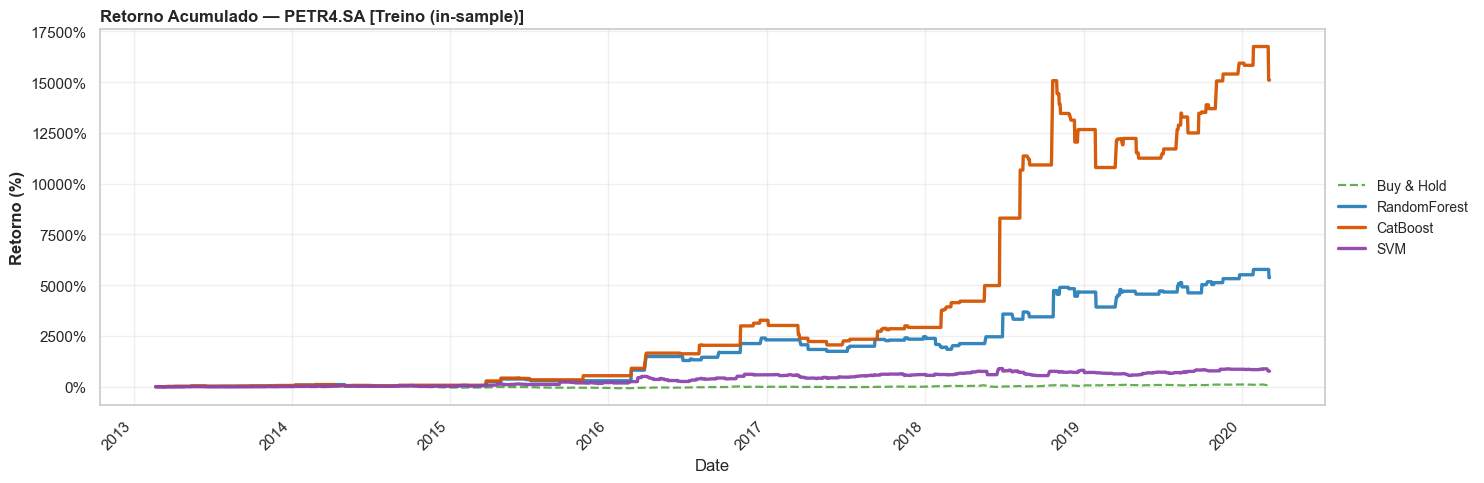

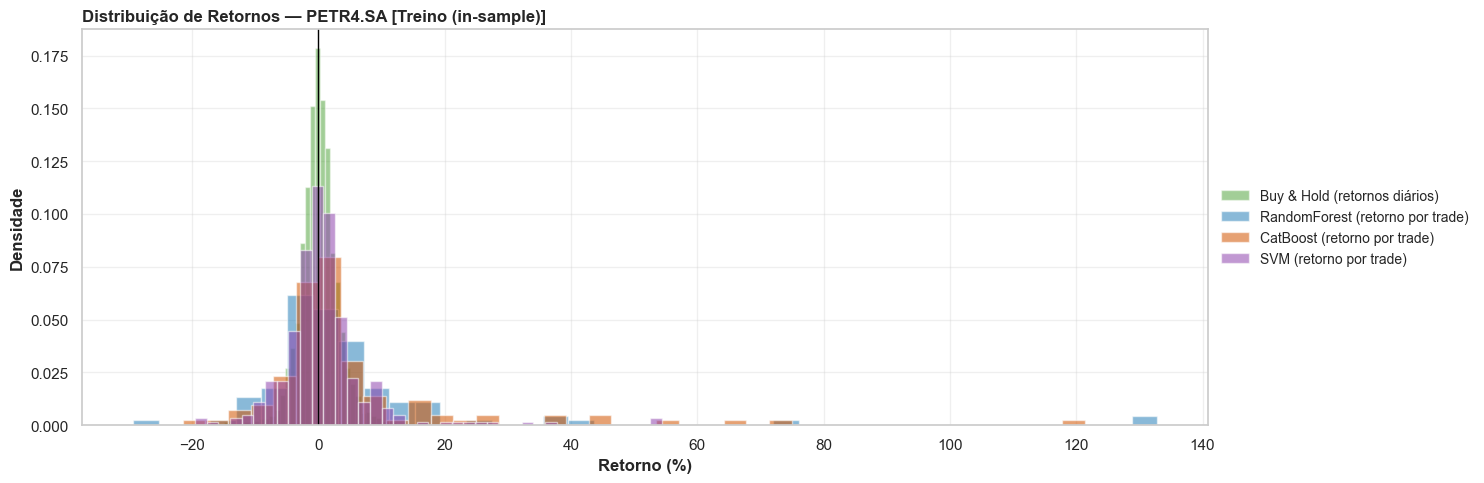

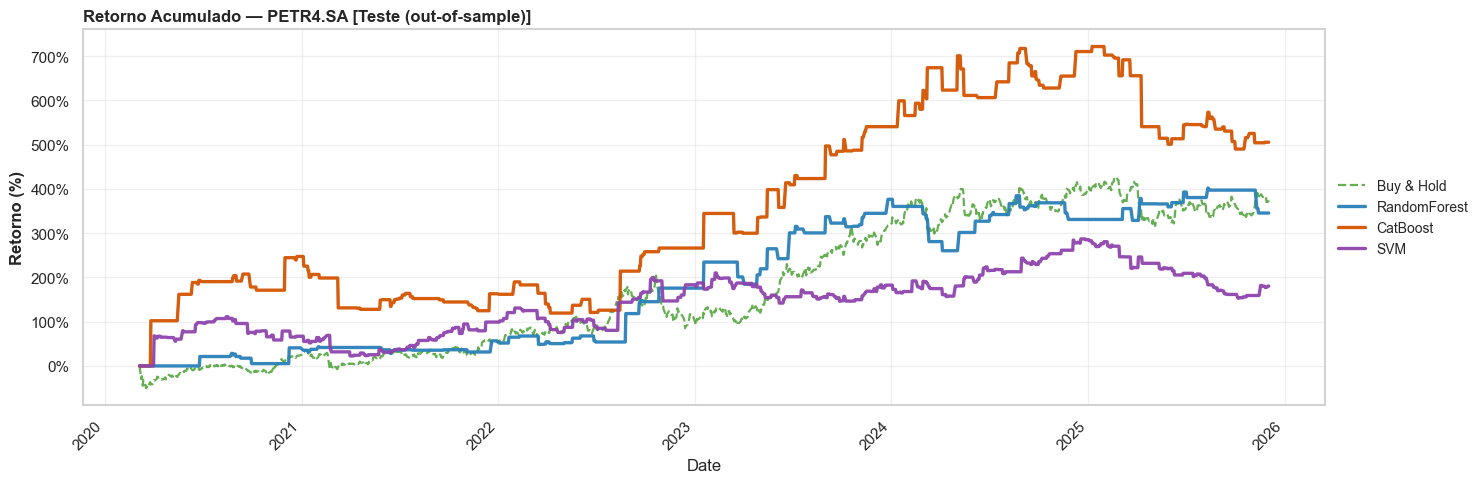

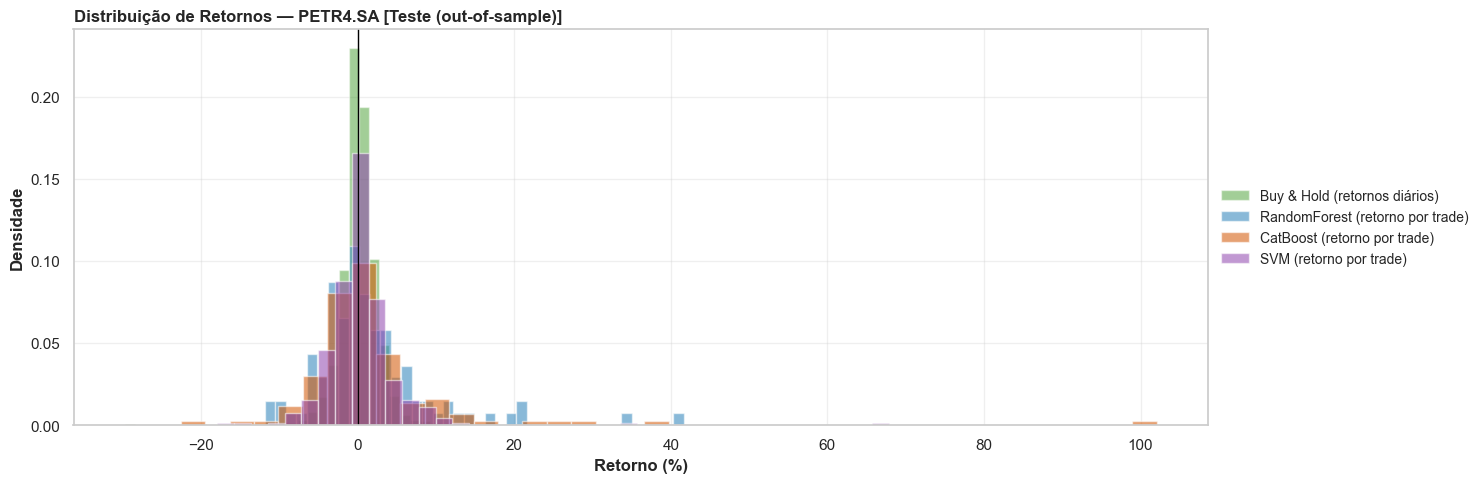

In [309]:
resultado_petr4_rf       = treinar_e_avaliar('PETR4.SA', 'RandomForest')
resultado_petr4_catboost = treinar_e_avaliar('PETR4.SA', 'CatBoost')
resultado_petr4_svm      = treinar_e_avaliar('PETR4.SA', 'SVM')

resultados_petr4 = {
    'RandomForest': resultado_petr4_rf,
    'CatBoost':     resultado_petr4_catboost,
    'SVM':          resultado_petr4_svm,
}

plotar_comparativo_ativo('PETR4.SA', resultados_petr4)


#### ABEV3.SA — Random Forest, CatBoost e SVM (comparativo)


ABEV3.SA — RandomForest
Accuracy train: 0.54
Accuracy test:  0.3659217877094972

Relatório de classificação (teste):
              precision    recall  f1-score   support

        -1.0       0.40      0.31      0.35       577
         0.0       0.32      0.58      0.41       362
         1.0       0.42      0.28      0.33       493

    accuracy                           0.37      1432
   macro avg       0.38      0.39      0.36      1432
weighted avg       0.39      0.37      0.36      1432



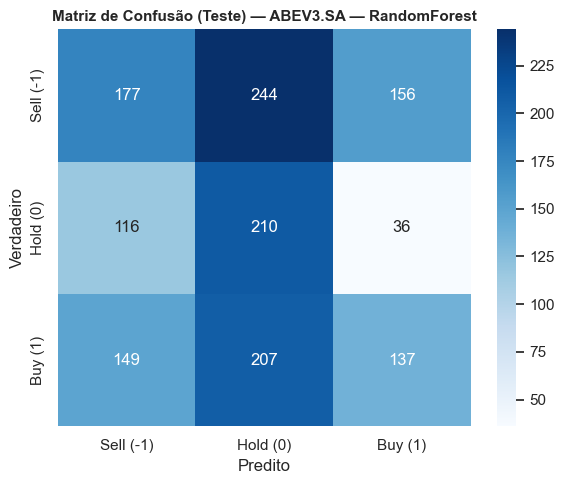


--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---
Trades total: 183 Trades positivos: 107 ( 58.47 %)
Media trades positivos:   3.09 %
Mediana trades positivos: 2.11 %
Media trades negativos:   -2.79 %
Mediana trades negativos: -1.85 %
Rent. buy and hold: 32.38 %
Rent. ML trade: 175.72 %

--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---
Trades total: 64 Trades positivos: 33 ( 51.56 %)
Media trades positivos:   4.15 %
Mediana trades positivos: 3.49 %
Media trades negativos:   -3.5 %
Mediana trades negativos: -2.64 %
Rent. Buy and Hold (Teste): 16.57 %
Rent. ML trade (Teste):     21.66 %
ABEV3.SA — CatBoost
Accuracy train: 0.5537142857142857
Accuracy test:  0.3680167597765363

Relatório de classificação (teste):
              precision    recall  f1-score   support

        -1.0       0.40      0.30      0.35       577
         0.0       0.31      0.57      0.40       362
         1.0       0.44      0.29      0.35       493

    accuracy                           0.37    

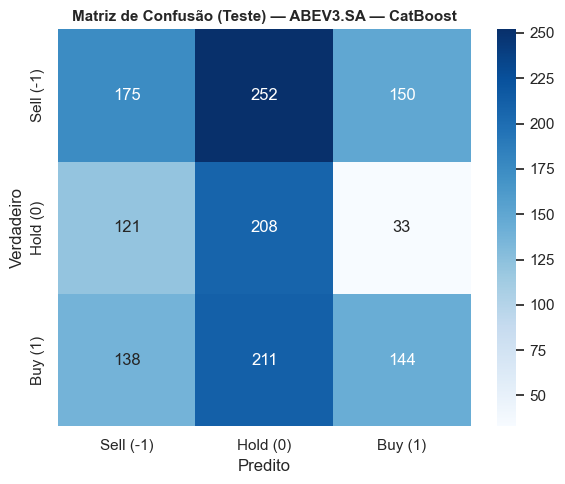


--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---
Trades total: 190 Trades positivos: 109 ( 57.37 %)
Media trades positivos:   3.12 %
Mediana trades positivos: 2.16 %
Media trades negativos:   -2.61 %
Mediana trades negativos: -1.67 %
Rent. buy and hold: 32.38 %
Rent. ML trade: 200.48 %

--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---
Trades total: 60 Trades positivos: 30 ( 50.0 %)
Media trades positivos:   4.5 %
Mediana trades positivos: 3.65 %
Media trades negativos:   -3.63 %
Mediana trades negativos: -3.06 %
Rent. Buy and Hold (Teste): 16.57 %
Rent. ML trade (Teste):     18.81 %
ABEV3.SA — SVM
Accuracy train: 0.42914285714285716
Accuracy test:  0.40083798882681565

Relatório de classificação (teste):
              precision    recall  f1-score   support

        -1.0       0.40      0.99      0.57       577
         0.0       0.00      0.00      0.00       362
         1.0       0.20      0.00      0.01       493

    accuracy                           0.40      14

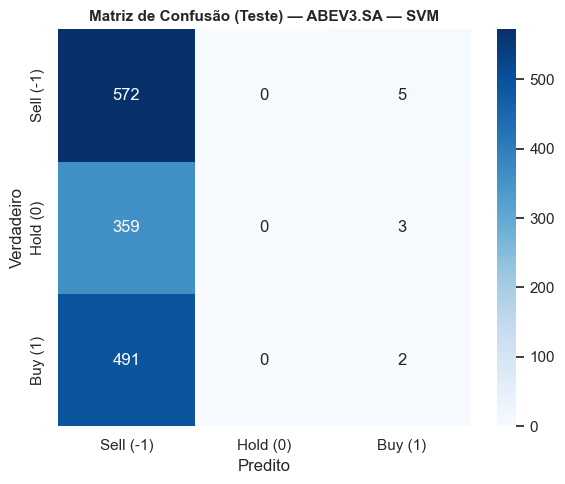


--- ESTATÍSTICAS DO PERÍODO INTEIRO (treino + teste) ---
Trades total: 40 Trades positivos: 16 ( 40.0 %)
Media trades positivos:   7.8 %
Mediana trades positivos: 4.12 %
Media trades negativos:   -5.51 %
Mediana trades negativos: -3.29 %
Rent. buy and hold: 32.38 %
Rent. ML trade: -25.77 %

--- ESTATÍSTICAS DO PERÍODO DE TESTE (out-of-sample) ---
Trades total: 10 Trades positivos: 6 ( 60.0 %)
Media trades positivos:   12.53 %
Mediana trades positivos: 3.94 %
Media trades negativos:   -11.46 %
Mediana trades negativos: -9.16 %
Rent. Buy and Hold (Teste): 16.57 %
Rent. ML trade (Teste):     14.39 %


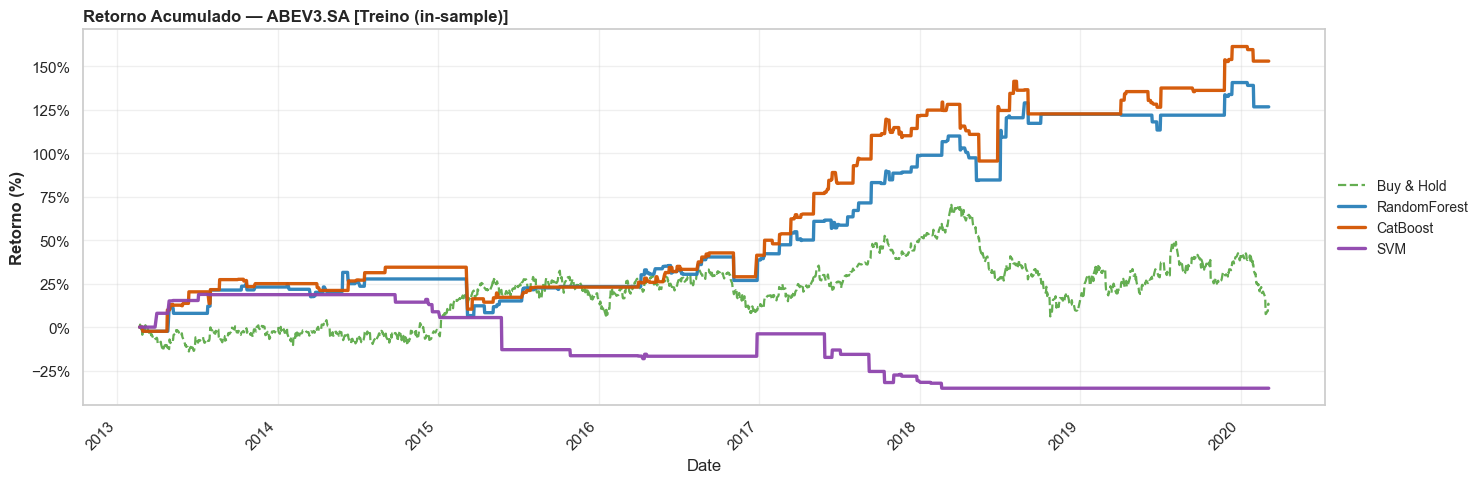

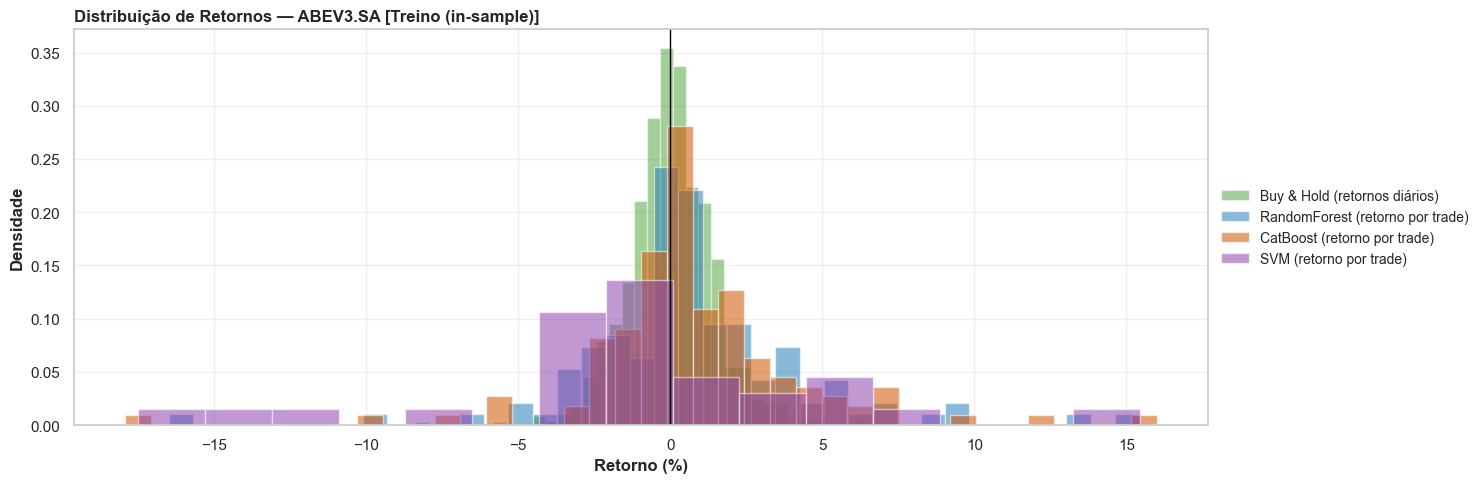

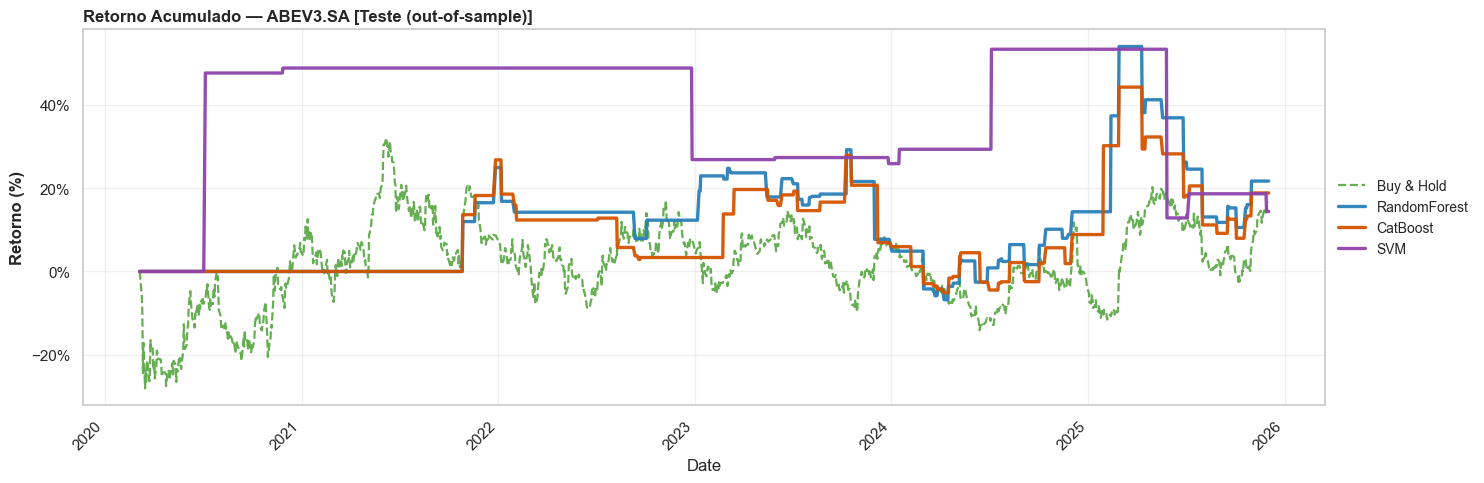

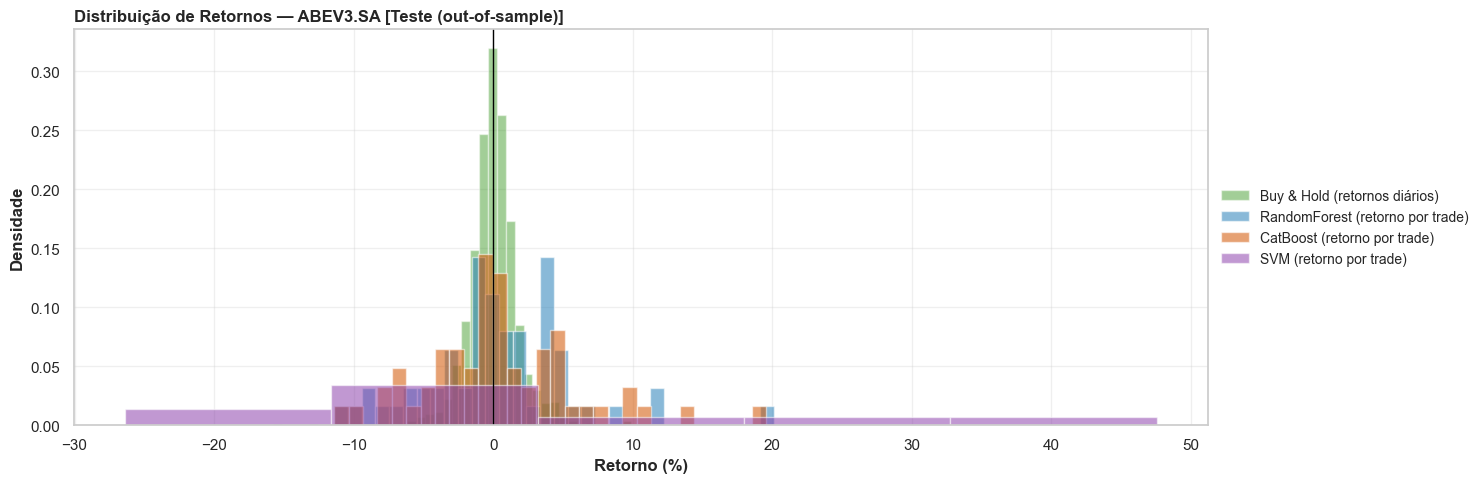

In [310]:
resultado_abev3_rf       = treinar_e_avaliar('ABEV3.SA', 'RandomForest')
resultado_abev3_catboost = treinar_e_avaliar('ABEV3.SA', 'CatBoost')
resultado_abev3_svm      = treinar_e_avaliar('ABEV3.SA', 'SVM')

resultados_abev3 = {
    'RandomForest': resultado_abev3_rf,
    'CatBoost':     resultado_abev3_catboost,
    'SVM':          resultado_abev3_svm,
}

plotar_comparativo_ativo('ABEV3.SA', resultados_abev3)


### **Tabela Descritiva (Período de Teste)**


In [311]:
def resumo_rentabilidade_teste(resultado, ticker, nome_modelo, train_n):
    """Extrai Rent. Buy & Hold vs Rent. Modelo no período de TESTE a partir do dict
    retornado por treinar_e_avaliar."""
    dados_ativo = resultado['dados']
    rent_bh = (dados_ativo['Close'].iloc[-1] / dados_ativo['Close'].iloc[train_n] - 1) * 100
    rent_ml = (dados_ativo['Saldo'].iloc[-1] / dados_ativo['Saldo'].iloc[train_n] - 1) * 100

    retornos_teste = resultado['retornos_trades_teste']
    n_trades_teste = len(retornos_teste)

    ret_pos = [r for r in retornos_teste if r > 0]
    ret_neg = [r for r in retornos_teste if r <= 0]

    media_pos = round(np.mean(ret_pos) * 100, 2) if len(ret_pos) > 0 else np.nan
    mediana_pos = round(np.median(ret_pos) * 100, 2) if len(ret_pos) > 0 else np.nan
    media_neg = round(np.mean(ret_neg) * 100, 2) if len(ret_neg) > 0 else np.nan
    mediana_neg = round(np.median(ret_neg) * 100, 2) if len(ret_neg) > 0 else np.nan

    return {
        'Ativo': ticker,
        'Modelo': nome_modelo,
        'Rent. Buy & Hold (Teste) %': round(rent_bh, 2),
        'Rent. Modelo (Teste) %': round(rent_ml, 2),
        'Nº trades (Teste)': n_trades_teste,
        'Média trades + (Teste) %': media_pos,
        'Mediana trades + (Teste) %': mediana_pos,
        'Média trades - (Teste) %': media_neg,
        'Mediana trades - (Teste) %': mediana_neg,
    }


linhas_resumo = []
combinacoes = [
    ('PETR4.SA', 'RandomForest', resultado_petr4_rf),
    ('PETR4.SA', 'CatBoost',     resultado_petr4_catboost),
    ('PETR4.SA', 'SVM',          resultado_petr4_svm),
    ('ABEV3.SA', 'RandomForest', resultado_abev3_rf),
    ('ABEV3.SA', 'CatBoost',     resultado_abev3_catboost),
    ('ABEV3.SA', 'SVM',          resultado_abev3_svm),
]

for ticker, nome_modelo, resultado in combinacoes:
    train_n_ativo = ATIVOS_PREPARADOS[ticker]['train_n']
    linhas_resumo.append(resumo_rentabilidade_teste(resultado, ticker, nome_modelo, train_n_ativo))

df_resumo = pd.DataFrame(linhas_resumo)
df_resumo

,Ativo,Modelo,Rent. Buy & Hold (Teste) %,Rent. Modelo (Teste) %,Nº trades (Teste),Média trades + (Teste) %,Mediana trades + (Teste) %,Média trades - (Teste) %,Mediana trades - (Teste) %
0,PETR4.SA,RandomForest,374.19,345.35,103,6.49,3.72,-3.48,-3.06
1,PETR4.SA,CatBoost,374.19,505.30,140,6.91,3.01,-3.53,-2.41
2,PETR4.SA,SVM,374.19,180.43,304,3.28,1.86,-2.51,-1.76
3,ABEV3.SA,RandomForest,16.57,21.66,64,4.15,3.49,-3.50,-2.64
4,ABEV3.SA,CatBoost,16.57,18.81,60,4.50,3.65,-3.63,-3.06
5,ABEV3.SA,SVM,16.57,14.39,10,12.53,3.94,-11.46,-9.16


In [312]:
print(df_resumo.to_markdown())

|    | Ativo    | Modelo       |   Rent. Buy & Hold (Teste) % |   Rent. Modelo (Teste) % |   Nº trades (Teste) |   Média trades + (Teste) % |   Mediana trades + (Teste) % |   Média trades - (Teste) % |   Mediana trades - (Teste) % |
|---:|:---------|:-------------|-----------------------------:|-------------------------:|--------------------:|---------------------------:|-----------------------------:|---------------------------:|-----------------------------:|
|  0 | PETR4.SA | RandomForest |                       374.19 |                   345.35 |                 103 |                       6.49 |                         3.72 |                      -3.48 |                        -3.06 |
|  1 | PETR4.SA | CatBoost     |                       374.19 |                   505.3  |                 140 |                       6.91 |                         3.01 |                      -3.53 |                        -2.41 |
|  2 | PETR4.SA | SVM          |                       374.19 |     